In [2]:
library(Seurat)
library(ggplot2)
library(ggunchained)
library(reshape2)
library(scop)
library(Signac)
set.seed(4180)
setwd("/")
cols <- c("#444576", "#4682B4", "#AEDEEE",
 "#FFD790", "#FFA500", "#C65762",
 "#FBDFDE", "#F6EFCF",
 "#BCB99F", "#4D4D4D")
pal <- colorRampPalette(cols)

In [2]:
mHeart <- readRDS("data/mHeart.rds")
mHeart

An object of class Seurat 
218817 features across 89514 samples within 2 assays 
Active assay: RNA (26111 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 1 other assay present: ATAC
 7 dimensional reductions calculated: pca, harmony, rlsi, lsi, umap, RNA.umap, ATAC.umap

In [4]:
mHeart <- FindNeighbors(mHeart, reduction = "harmony", dims = 1:30)

Computing nearest neighbor graph

Computing SNN



In [9]:
mHeart <- FindClusters(mHeart, random.seed = 4180,resolution = 2)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 89514
Number of edges: 2829130

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8151
Number of communities: 36
Elapsed time: 37 seconds


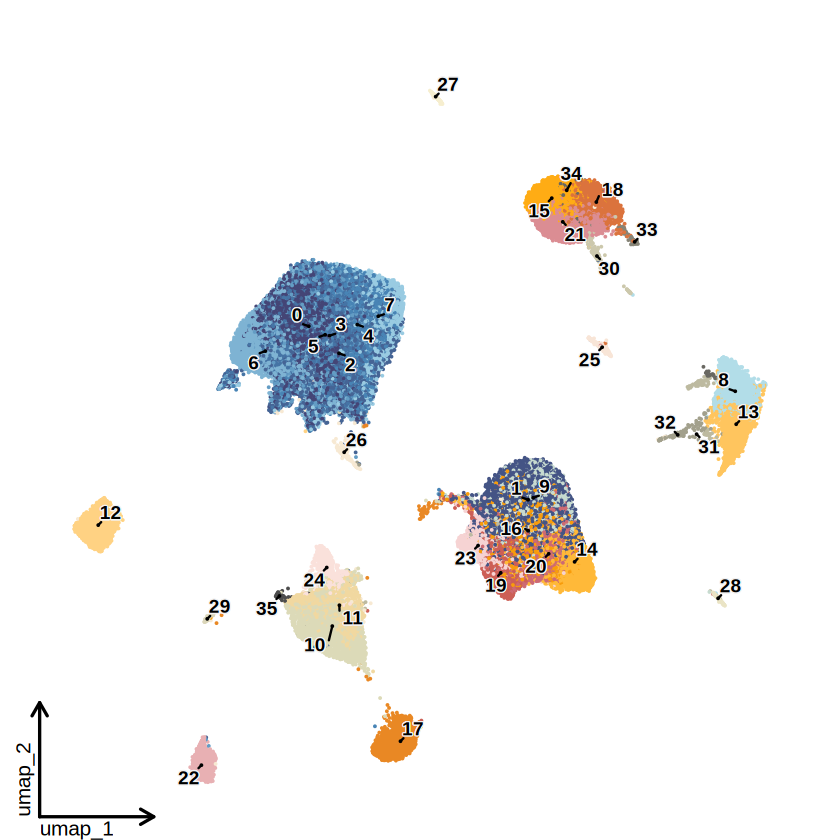

In [10]:
CellDimPlot(
 srt = subset(mHeart), group.by = "seurat_clusters", legend.position = "none",
 label_repel = TRUE, label_point_size = 0.01, reduction = "umap",
 label = TRUE, label_insitu = TRUE, theme_use = "theme_blank",
 label.fg = "black", label.bg = "grey95", label.bg.r = 0.1,
 title = "", palcolor = pal(36), ncol = 1,
 bg_color = "grey90", raster = FALSE
)

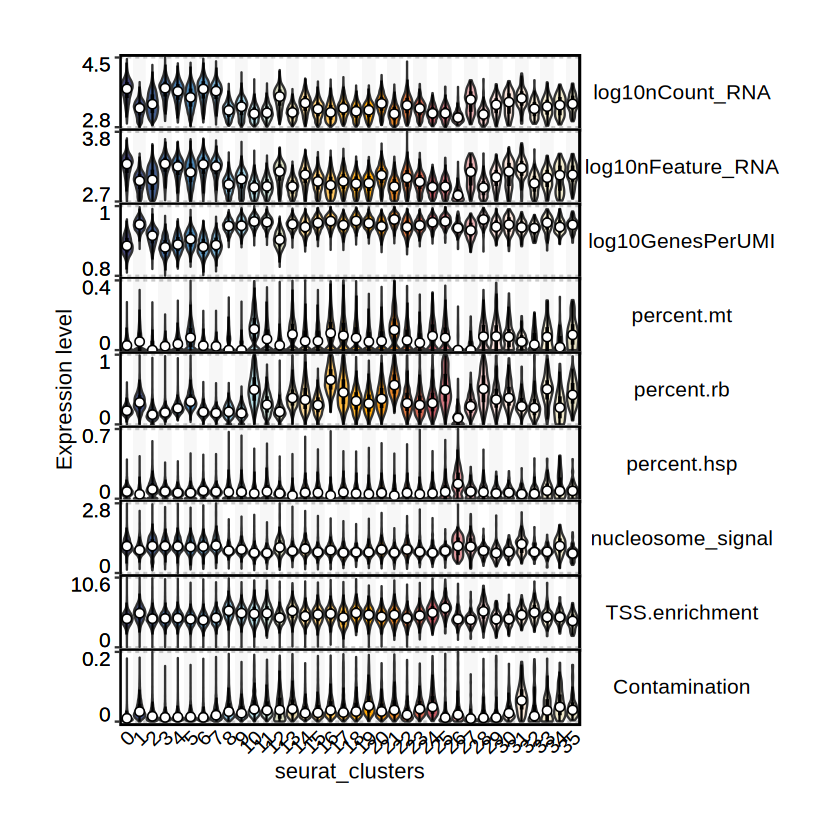

In [11]:
FeatureStatPlot(
 mHeart,
 group.by = "seurat_clusters",
 stat.by = c("log10nCount_RNA", 
 "log10nFeature_RNA", 
 "log10GenesPerUMI", 
 "percent.mt",
 "percent.rb",
 "percent.hsp",
 "nucleosome_signal",
 "TSS.enrichment",
 "Contamination"),
 add_box = TRUE,stack = T,palcolor = pal(44)
)

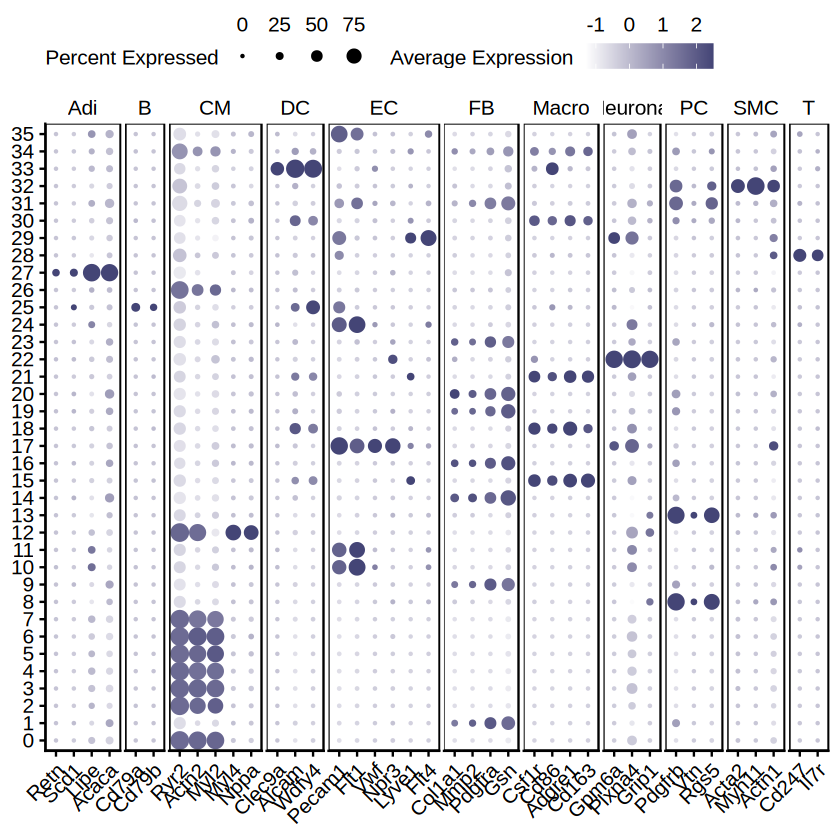

In [14]:
#plot markers
# cell annotation
# get markers
marker <- readxl::read_excel("database/Marker.xlsx")
markers.to.plot <- unique(marker$gene)
markers.to.plot <- split(marker$gene, marker$celltype)
DotPlot(mHeart,
 dot.scale = 4, group.by = "seurat_clusters",
 features = c(markers.to.plot),
 cols = c("white", pal(1)),
 assay = "RNA"
) +
 RotatedAxis() + #seurat
 theme(
 legend.position = "top",
 legend.title = element_text(size = 12),
 strip.text = element_text(), # facet strip text
 panel.border = element_rect(color = "black"),
 panel.spacing = unit(1, "mm"),
 axis.title = element_blank()
 ) +
 guides(
 colour = guide_colourbar(title.vjust = 0.1,
 title.hjust = 0,
 label.position = "top"),
 size = guide_legend(title.vjust = 0.1,
 title.hjust = 0,
 label.position = "top")
 ) +
 labs(size = "Percent Expressed", color = "Average Expression")

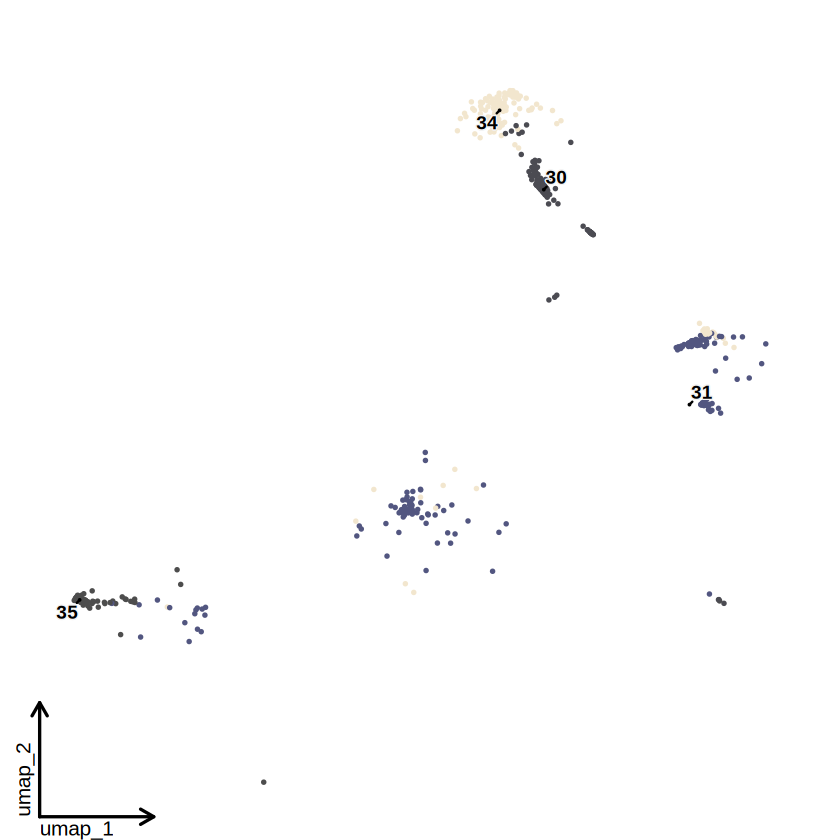

In [27]:
CellDimPlot(
 srt = subset(mHeart , seurat_clusters %in% c(26,30,31,34,35)),
 group.by = "seurat_clusters", legend.position = "none",
 label_repel = TRUE, label_point_size = 0.01, reduction = "umap",
 label = TRUE, label_insitu = TRUE, theme_use = "theme_blank",
 label.fg = "black", label.bg = "grey95", label.bg.r = 0.1,
 title = "", palcolor = c(pal(30),pal(5)), ncol = 1,
 bg_color = "grey90", raster = FALSE
)

In [39]:
mHeart <- subset(mHeart, !seurat_clusters %in% c(26,30,31,34,35))

In [41]:
# Change cell types
mHeart@active.ident <- factor(mHeart$seurat_clusters)
new.cluster.ids <- c(
 "vCM", "FB", "vCM", "vCM", "vCM", "vCM", "vCM", "vCM",
 "Pericyte", "FB", "EC", "EC", "aCM", "Pericyte", "FB",
 "Macrophage", "FB", "EndoCC", "Macrophage", "FB", "FB",
 "Macrophage", "Neuronal", "FB", "EC", "B",
 "Adipocyte", "T", "LEC", "SMC", "DC"
 
)
names(new.cluster.ids) <- levels(mHeart)
mHeart <- RenameIdents(mHeart, new.cluster.ids)
mHeart$celltype <- mHeart@active.ident
mHeart$celltype <- factor(mHeart$celltype,
 levels = c(
 "vCM", "aCM", "FB", "EC", "EndoCC", "LEC", "SMC", "Pericyte",
 "Adipocyte", "Neuronal", "T", "B", "Macrophage", "DC"
 )
)
mHeart@active.ident <- mHeart$celltype

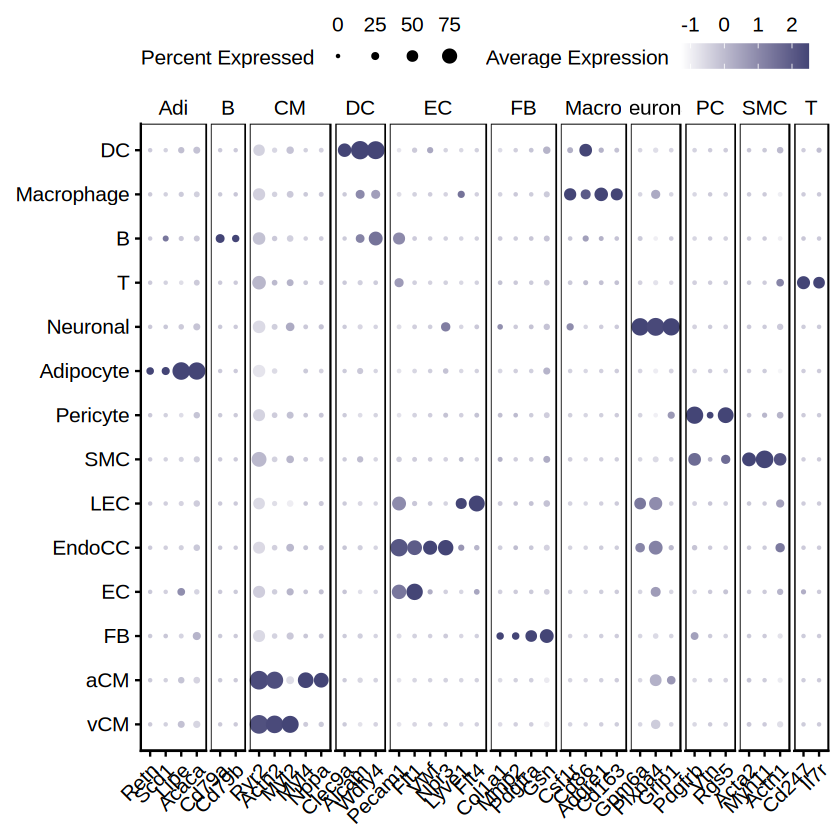

In [42]:
DotPlot(mHeart,
 dot.scale = 4, group.by = "celltype",
 features = c(markers.to.plot),
 cols = c("white", pal(1))
) +
 RotatedAxis() + #seurat
 theme(
 legend.position = "top",
 legend.title = element_text(size = 12),
 strip.text = element_text(), # facet strip text
 panel.border = element_rect(color = "black"),
 panel.spacing = unit(1, "mm"),
 axis.title = element_blank()
 ) +
 guides(
 colour = guide_colourbar(title.vjust = 0.1,
 title.hjust = 0,
 label.position = "top"),
 size = guide_legend(title.vjust = 0.1,
 title.hjust = 0,
 label.position = "top")
 ) +
 labs(size = "Percent Expressed", color = "Average Expression")

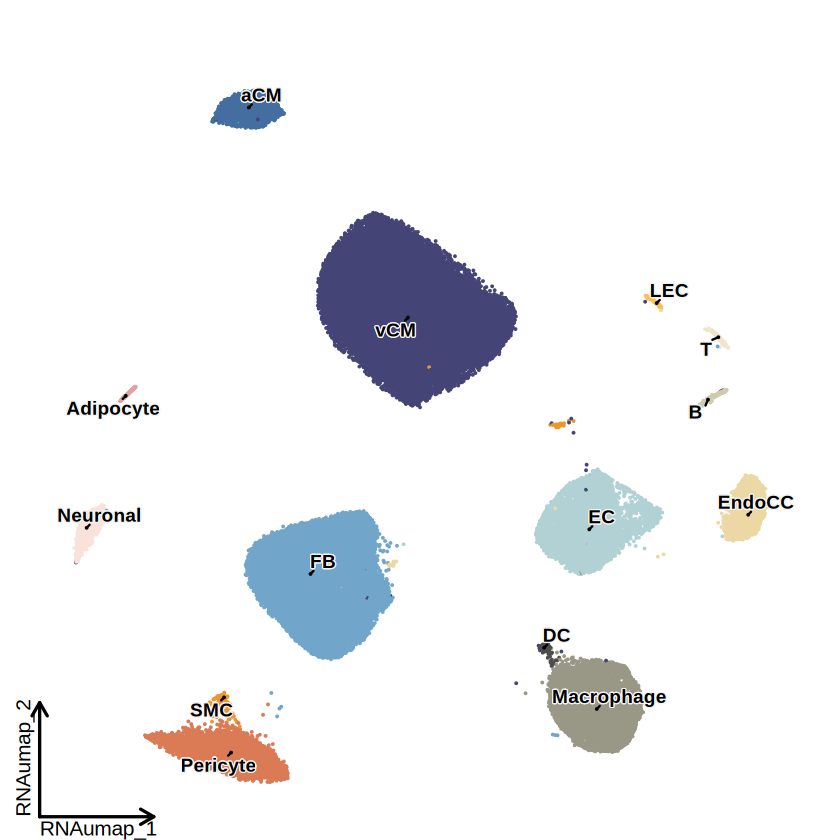

In [43]:
CellDimPlot(
 srt = mHeart, group.by = "celltype", legend.position = "none",
 label_repel = TRUE, label_point_size = 0.01, reduction = "RNA.umap",
 label = TRUE, label_insitu = TRUE, theme_use = "theme_blank",
 label.fg = "black", label.bg = "grey95", label.bg.r = 0.1,
 title = "", palcolor = pal(13), ncol = 1,
 bg_color = "grey90", raster = FALSE
)

In [44]:
saveRDS(mHeart, "data/mHeart.Rds")

In [ ]:
mHeart <- readRDS("data/mHeart.rds")

In [45]:
mHeart_ATAC <- mHeart
DefaultAssay(mHeart_ATAC) <- 'ATAC'
mHeart_ATAC@assays <- mHeart_ATAC@assays[2]

In [47]:
#ATAC analysis
library(EnsDb.Mmusculus.v79)
library(BSgenome.Mmusculus.UCSC.mm10)
library(GenomeInfoDb)
# prepare data
DefaultAssay(mHeart_ATAC) <- 'ATAC'
#change path
sample_name <- c(
 "NP1", "NP2", "NP3",
 "EP1", "EP2", "EP3",
 "MP1", "MP2", "MP3",
 "LP1", "LP2", "LP3",
 "PP1", "PP2", "PP3"
)
peaks.keep <- seqnames(granges(mHeart_ATAC)) %in% standardChromosomes(granges(mHeart_ATAC))
mHeart_ATAC <- mHeart_ATAC[as.vector(peaks.keep), ]
# Annotation
annotation <- GetGRangesFromEnsDb(EnsDb.Mmusculus.v79)
seqlevels(annotation) <- paste0("chr", seqlevels(annotation))
genome(annotation) <- "mm10"
Annotation(mHeart_ATAC) <- annotation
# run
mHeart_ATAC <- RunTFIDF(mHeart_ATAC)
mHeart_ATAC <- FindTopFeatures(mHeart_ATAC, min.cutoff = 'q0')
mHeart_ATAC<- RunSVD(mHeart_ATAC)
mHeart_ATAC <- RegionStats(mHeart_ATAC, genome = BSgenome.Mmusculus.UCSC.mm10)

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

In [48]:
#save result
saveRDS(mHeart_ATAC, "data/mHeart_ATAC.Rds")
DefaultAssay(mHeart) <- 'RNA'
mHeart@assays <- mHeart@assays[1]
saveRDS(mHeart, "data/mHeart.Rds")

In [49]:
mHeart
mHeart_ATAC

An object of class Seurat 
26111 features across 88417 samples within 1 assay 
Active assay: RNA (26111 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 7 dimensional reductions calculated: pca, harmony, rlsi, lsi, umap, RNA.umap, ATAC.umap

An object of class Seurat 
192633 features across 88417 samples within 1 assay 
Active assay: ATAC (192633 features, 192633 variable features)
 2 layers present: counts, data
 6 dimensional reductions calculated: harmony, rlsi, lsi, umap, RNA.umap, ATAC.umap

In [50]:
#motif analysis
pfm <- readRDS("data/cisBP_mouse_pfms_2021.rds")
mHeart_ATAC <- AddMotifs(
 object = mHeart_ATAC,
 genome = BSgenome.Mmusculus.UCSC.mm10,
 pfm = pfm
)
saveRDS(mHeart_ATAC, "data/mHeart_ATAC.Rds")

Building motif matrix

Warning message in .merge_two_Seqinfo_objects(x, y):
"Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL455991_alt, chr1_GL455992_alt, chr1_GL455993_alt, chr1_GL456005_alt, chr1_JH584315_alt, chr1_JH584320_alt, chr1_JH584321_alt, chr1_JH584322_alt, chr2_GL456024_alt, chr3_GL456006_alt, chr3_GL456007_alt, chr3_GL456008_alt, chr3_GL456042_alt, chr3_GL456044_alt, chr3_GL456045_alt, chr3_GL456048_alt, chr3_GL456049_alt, chr3_JH584323_alt, chr4_GL455994_alt, chr4_GL456009_alt, chr4_GL456010_alt, chr4_GL456053_alt, chr4_GL456064_alt, chr4_GL456075_alt, chr4_GL456076_alt, chr4_GL456077_alt, chr4_JH584268_alt, chr4_JH584269_alt, chr4_JH584324_alt, chr4_JH584325_alt, chr4_JH584326_alt, chr5_GL455995_alt, chr5_GL456011_alt, chr6_GL456012_alt, chr6_GL456025_alt, chr6_GL456026_alt, chr6_GL456054_alt, chr6_GL456065_alt, chr6_JH584264_alt, chr7_GL455989_alt, chr7_GL456013_alt, chr7_GL456014_alt, chr8_GL455996_alt, chr8_GL455997_alt, 

In [51]:
mHeart_ATAC <- RunChromVAR(
 object = mHeart_ATAC,
 genome = BSgenome.Mmusculus.UCSC.mm10,
 new.assay.name = "motif"
)
obj <- mHeart_ATAC
DefaultAssay(obj) <- 'motif'
obj@assays <- obj@assays[2]
saveRDS(obj, "data/motif.Rds")

Computing GC bias per region

Warning message in .merge_two_Seqinfo_objects(x, y):
"Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL455991_alt, chr1_GL455992_alt, chr1_GL455993_alt, chr1_GL456005_alt, chr1_JH584315_alt, chr1_JH584320_alt, chr1_JH584321_alt, chr1_JH584322_alt, chr2_GL456024_alt, chr3_GL456006_alt, chr3_GL456007_alt, chr3_GL456008_alt, chr3_GL456042_alt, chr3_GL456044_alt, chr3_GL456045_alt, chr3_GL456048_alt, chr3_GL456049_alt, chr3_JH584323_alt, chr4_GL455994_alt, chr4_GL456009_alt, chr4_GL456010_alt, chr4_GL456053_alt, chr4_GL456064_alt, chr4_GL456075_alt, chr4_GL456076_alt, chr4_GL456077_alt, chr4_JH584268_alt, chr4_JH584269_alt, chr4_JH584324_alt, chr4_JH584325_alt, chr4_JH584326_alt, chr5_GL455995_alt, chr5_GL456011_alt, chr6_GL456012_alt, chr6_GL456025_alt, chr6_GL456026_alt, chr6_GL456054_alt, chr6_GL456065_alt, chr6_JH584264_alt, chr7_GL455989_alt, chr7_GL456013_alt, chr7_GL456014_alt, chr8_GL455996_alt, chr8_GL45599

In [3]:
mHeart_ATAC <- readRDS("data/mHeart_ATAC.Rds")

In [52]:
# gene activity
library(future.apply)
library(future)
activity.list <- list()
sample_name <- c(
 "NP1", "NP2", "NP3",
 "EP1", "EP2", "EP3",
 "MP1", "MP2", "MP3",
 "LP1", "LP2", "LP3",
 "PP1", "PP2", "PP3"
)
# multi cores
options(future.globals.maxSize = 50 * 1024^3)
plan(multicore, workers = 15)
# initialize
activity.list <- vector("list", length = 15)
sample_names <- sample_name[1:15]
# future_lapply
results <- future_lapply(seq_along(sample_names), function(i) {
 sampleid <- sample_names[i]
 data_dir <- "data/"
 # Subset object
 sub_obj <- subset(mHeart_ATAC, id %in% sampleid)
 old_colnames <- colnames(sub_obj)
 # Clean cell names
 new_colnames <- gsub(paste0(sampleid, "_"), "", colnames(sub_obj))
 colnames(sub_obj) <- new_colnames
 # Create Fragment Object
 fragpath <- file.path(data_dir, sampleid, "outs/atac_fragments.tsv.gz")
 frags.pbmc <- CreateFragmentObject(
 path = fragpath,
 cells = colnames(sub_obj)
 )
 # Assign fragments back to sub_obj
 sub_obj@assays$ATAC@fragments[[i]] <- frags.pbmc
 # Calculate Gene Activity
 activity <- GeneActivity(sub_obj)
 # Return the result
 colnames(activity) <- old_colnames
 return(list(
 activity = activity,
 cell_names = old_colnames # used for later verification
 ))
})
activity.list <- lapply(results, function(x) x$activity)
combined_activity <- do.call(cbind, activity.list)

Computing hash

Extracting gene coordinates

Warning message in SingleFeatureMatrix(fragment = fragments[[x]], features = features, :
"13 features are on seqnames not present in the fragment file. These will be removed."
Extracting reads overlapping genomic regions

Warning message:
"UNRELIABLE VALUE: One of the 'future.apply' iterations ('future_lapply-1') unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future 'future_lapply-1' (0f988b41c08ad7a636f81d864b59175a-2); on 0f988b41c08ad7a636f81d864b59175a@x86_64-conda-linux-gnu<223001>]"
Computing hash

Extracting gene coordinates

Warning message in SingleFeatureMatrix(fragment = fragme

In [53]:
#save result
mHeart_ATAC[['activity']] <- CreateAssayObject(counts = combined_activity)
mHeart_ATAC <- NormalizeData(
 object = mHeart_ATAC,
 assay = 'activity',
 normalization.method = 'LogNormalize',
 scale.factor = median(mHeart_ATAC$nCount_activity)
)
obj <- mHeart_ATAC
DefaultAssay(obj) <- 'activity'
obj@assays <- obj@assays[3]
saveRDS(obj, "data/activity.Rds")

In [54]:
#Gene AUCell
library(irGSEA)
# code modified by https://rdrr.io/github/cashoes/sear/src/data-raw/1_parse_msigdb_sqlite.r
con <- DBI::dbConnect(RSQLite::SQLite(), dbname = "data/msigdb_v2026.1.Mm.db")
DBI::dbListTables(con)
# define tables we want to combine
geneset_db <- dplyr::tbl(con, "gene_set") # standard_name, collection_name
details_db <- dplyr::tbl(con, "gene_set_details") # description_brief, description_full
geneset_genesymbol_db <- dplyr::tbl(con, "gene_set_gene_symbol") # meat and potatoes
genesymbol_db <- dplyr::tbl(con, "gene_symbol") # mapping from ids to gene symbols
collection_db <- dplyr::tbl(con, "collection") %>% dplyr::select(collection_name, full_name) # collection metadata

# join tables
msigdb <- geneset_db %>%
 dplyr::left_join(details_db, by = c("id" = "gene_set_id")) %>%
 dplyr::left_join(collection_db, by = "collection_name") %>%
 dplyr::left_join(geneset_genesymbol_db, by = c("id" = "gene_set_id")) %>%
 dplyr::left_join(genesymbol_db, by = c("gene_symbol_id" = "id")) %>%
 dplyr::select(collection = collection_name, subcollection = full_name, geneset = standard_name, description = description_brief, symbol) %>%
 dplyr::as_tibble()

# clean up
DBI::dbDisconnect(con)
table(msigdb$collection)

[1] "MSigDB"                              
 [2] "author"                              
 [3] "collection"                          
 [4] "external_term"                       
 [5] "external_term_filtered_by_similarity"
 [6] "gene_set"                            
 [7] "gene_set_details"                    
 [8] "gene_set_gene_symbol"                
 [9] "gene_set_license"                    
[10] "gene_set_source_member"              
[11] "gene_symbol"                         
[12] "namespace"                           
[13] "publication"                         
[14] "publication_author"                  
[15] "source_member"                       
[16] "species"                             
[17] "sqlite_stat1"                        
[18] "sqlite_stat4"


                M1             M2:CGP     M2:CP:BIOCARTA     M2:CP:REACTOME 
             41400             116378               3959              75097 
M2:CP:WIKIPATHWAYS            M3:GTRD           M3:MIRDB           M5:GO:BP 
             10785             163326             233370             651755 
          M5:GO:CC           M5:GO:MF             M5:MPT                 M7 
            112349             114117               2606              70547 
                M8                 MH 
             47976               7191 

In [55]:
msigdb.go.bp <- msigdb %>% 
 dplyr::filter(collection=="M5:GO:BP") %>% 
 dplyr::select(c("geneset", "symbol"))
msigdb.go.bp$geneset <- factor(msigdb.go.bp$geneset)
msigdb.go.bp <- msigdb.go.bp %>% 
 dplyr::group_split(geneset, .keep = F) %>%
 purrr::map( ~.x %>% dplyr::pull(symbol) %>% unique(.)) %>%
 purrr::set_names(levels(msigdb.go.bp$geneset))
head(msigdb.go.bp)

$GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS
[1] "Mthfd1l"  "Aldh1l2"  "Mthfd1"   "Mthfd2l"  "Aldh1l1"  "Aasdhppt"

$GOBP_2_OXOGLUTARATE_METABOLIC_PROCESS
 [1] "Col6a1" "Ogdh"   "Dld"    "Dlst"   "Mrps36" "Ogdhl"  "Got1"   "Idh1"  
 [9] "Phyh"   "Kyat3"  "Idh2"   "Aadat"  "Gpt2"   "Got2"   "Tat"   

$GOBP_2FE_2S_CLUSTER_ASSEMBLY
 [1] "Glrx5"   "Lyrm4"   "Fxn"     "Nfs1"    "Iscu"    "Hscb"    "Ndufab1"
 [8] "Bola2"   "Glrx3"   "Fdx2"   

$GOBP_3_UTR_MEDIATED_MRNA_DESTABILIZATION
 [1] "Zc3h12d" "Zfp36l1" "Rbm24"   "Khnyn"   "Nynrin"  "Qki"     "Khsrp"  
 [8] "Zfp36l2" "Dnd1"    "Cpeb3"   "Rc3h1"   "Dhx36"   "Mov10"   "Zc3h12a"
[15] "Tardbp"  "Plekhn1" "Hnrnpd"  "Zfp36"   "Upf1"    "Zc3h12c" "Trim71" 
[22] "Zc3h12b"

$GOBP_3_UTR_MEDIATED_MRNA_STABILIZATION
 [1] "Mettl16"  "Stat3"    "Larp4b"   "Adarb2"   "Rbm24"    "Hnrnpa0" 
 [7] "Tent4a"   "Qki"      "Dazl"     "Jak2"     "Arid5a"   "Boll"    
[13] "Mapkapk2" "Angel2"   "Mir466l"  "Rbm38"    "Elavl4"   "Tardbp"  
[19] "Nicol1"   "Rbm47"    "Zfp36"    "Elavl1"   "Tent4b"   "Tirap"   
[25] "Myd88"    "Rbm10"   

$GOBP_4FE_4S_CLUSTER_ASSEMBLY
[1] "Lyrm4" "Fxn"   "Nfs1"  "Iscu"  "Fdx2"

In [56]:
DefaultAssay(mHeart) <- 'RNA'
mHeart <- irGSEA.score(object = mHeart , assay = "RNA", slot = "data",
 custom = T, geneset = msigdb.go.bp,
 method = c("AUCell"),
 kcdf = 'Gaussian')
obj <- mHeart
DefaultAssay(obj) <- 'AUCell'
obj@assays <- obj@assays[2]
saveRDS(obj, "data/ge_AUCell.Rds")

Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc 'pca'

Updating matrix keys for DimReduc 'harmony'

Updating matrix keys for DimReduc 'rlsi'



Updating matrix keys for DimReduc 'lsi'

Updating matrix keys for DimReduc 'umap'

Updating matrix keys for DimReduc 'RNA.umap'

Updating matrix keys for DimReduc 'ATAC.umap'

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Updating slots in wknn

Cannot find wknn in the object, setting default assay of wknn to RNA

Updating slots in wsnn

Cannot find wsnn in the object, setting default assay of wsnn to RNA

Updating slots in RNA_nn

Setting default assay of RNA_nn to RNA

Updating slots in RNA_snn

Setting default assay of RNA_snn to RNA

Updating slots in pca

Updating slots in harmony

Updating slots in rlsi

Updating slots in lsi

Updating slots in umap

Setting umap DimReduc to global

Updating slots in RNA.umap

Setting RNA.umap DimReduc to global

Updating slots in ATAC.umap

Setting ATAC.umap DimReduc to global

Setting assay used for NormalizeData.RNA to RNA

Setting assay used for FindVariableFeatures.R

In [57]:
mHeart <- readRDS("data/activity.Rds")

In [58]:
mHeart <- irGSEA.score(object = mHeart, assay = "activity", slot = "data",
 custom = T, geneset = msigdb.go.bp,
 method = c("AUCell"),
 kcdf = 'Gaussian')
mHeart
obj <- mHeart
DefaultAssay(obj) <- 'AUCell'
obj@assays <- obj@assays[2]
saveRDS(obj, "data/ac_AUCell.Rds")

Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc 'harmony'

Updating matrix keys for DimReduc 'rlsi'



Updating matrix keys for DimReduc 'lsi'

Updating matrix keys for DimReduc 'umap'

Updating matrix keys for DimReduc 'RNA.umap'

Updating matrix keys for DimReduc 'ATAC.umap'

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in activity

Updating slots in wknn

Cannot find wknn in the object, setting default assay of wknn to activity

Updating slots in wsnn

Cannot find wsnn in the object, setting default assay of wsnn to activity

Updating slots in RNA_nn

Cannot find RNA in the object, setting default assay of RNA_nn to activity

Updating slots in RNA_snn

Cannot find RNA in the object, setting default assay of RNA_snn to activity

Updating slots in harmony

Updating slots in rlsi

Updating slots in lsi

Updating slots in umap

Setting umap DimReduc to global

Updating slots in RNA.umap

Setting RNA.umap DimReduc to global

Updating slots in ATAC.umap

Setting ATAC.umap DimReduc to global

No assay information could be 

An object of class Seurat 
29338 features across 88417 samples within 2 assays 
Active assay: activity (21808 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: AUCell
 6 dimensional reductions calculated: harmony, rlsi, lsi, umap, RNA.umap, ATAC.umap

In [ ]:
#tolower BOBP_xxxxxx 
df$Clean_Term <- tolower(gsub("_", " ", gsub("^GOBP_", "", df$GO_term)))